In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "Dataset/Train",
    image_size=(224 , 224),
    batch_size=16, #عدد الصور الي بيشوفها الموديل قبل ما يغير الوزن
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "Dataset/Validation",
    image_size=(224 , 224),
    batch_size=16, #عدد الصور الي بيشوفها الموديل قبل ما يغير الوزن
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Dataset/Test",
    image_size=(224 , 224),
    batch_size=16, #عدد الصور الي بيشوفها الموديل قبل ما يغير الوزن
    label_mode='binary'
)

Found 140002 files belonging to 2 classes.
Found 39428 files belonging to 2 classes.
Found 10905 files belonging to 2 classes.


In [ ]:
model1 = tf.keras.Sequential([
    layers.Input((224,224,3)),

    layers.Conv2D(32, 3, activation='relu', padding='same'), #relu هي دالة تنشيط بتخلي الموديل non-leanier فيعرف يفرق بين الملامح ويصنف الصور بشكل صحيح
    layers.MaxPooling2D(), #MaxPooling2D بتقلل حجم الصورة عشان الموديل بس يركز على الملامح المهمة الي بتفرق بين كل صورة والثانية

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(), #بتحول الصورة من شكلها الاصلي الي شكل خطي عشان نقدر ندخلها في الطبقات الكثيفة
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history1 = model1.fit(train_ds,validation_data=val_ds, epochs=10)

Epoch 1/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1360s 155ms/step - accuracy: 0.7527 - auc: 0.8300 - loss: 0.9929 - val_accuracy: 0.7983 - val_auc: 0.8942 - val_loss: 0.4485
Epoch 2/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1373s 157ms/step - accuracy: 0.9287 - auc: 0.9805 - loss: 0.1772 - val_accuracy: 0.8413 - val_auc: 0.9244 - val_loss: 0.4005
Epoch 3/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1377s 157ms/step - accuracy: 0.9579 - auc: 0.9927 - loss: 0.1051 - val_accuracy: 0.8260 - val_auc: 0.9100 - val_loss: 0.5690
Epoch 4/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1400s 160ms/step - accuracy: 0.9744 - auc: 0.9969 - loss: 0.0665 - val_accuracy: 0.8583 - val_auc: 0.9289 - val_loss: 0.5647
Epoch 5/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1407s 161ms/step - accuracy: 0.9813 - auc: 0.9982 - loss: 0.0482 - val_accuracy: 0.8616 - val_auc: 0.9335 - val_loss: 0.5771
Epoch 6/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1547s 177ms/step - accuracy: 0.9861 - auc: 0.9986 - loss: 0.0383 - val_accuracy: 0.8139 - val_auc: 0.8941 - val_loss: 0.990

In [5]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    prob = model1.predict(images).ravel()
    preds = (prob > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(prob)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━

In [6]:
print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
print("Precision:", round(precision_score(y_true, y_pred), 3))
print("Recall:", round(recall_score(y_true, y_pred), 3))
print("F1-score:", round(f1_score(y_true, y_pred), 3))
print(f"AUC: {round(roc_auc_score(y_true, y_prob), 3)}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.942
Precision: 0.934
Recall: 0.951
F1-score: 0.942
AUC: 0.982

Confusion Matrix:
[[18301  1340]
 [  962 18825]]


In [ ]:
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))  # EfficientNetB0 هو موديل مدرب مسبقاً على صور من انترنت وبيستخدم في تصنيف الصور
base_model.trainable = False  # تجميد أوزان الموديل الأساسي وما نعدّلها أثناء التدريب

inputs = layers.Input(shape=(224,224,3))  # تعريف شكل الصورة اللي راح تدخل على الموديل
x = base_model(inputs, training=False)    # تمرير الصورة بالموديل الجاهز بدون تحديث أوزانه
x = layers.GlobalAveragePooling2D()(x)    # تحويل الفيتشر مابس لمتجه واحد بأخذ المتوسط
x = layers.Dropout(0.4)(x)                # إطفاء 40% من القيم وقت التدريب لتقليل الـoverfitting
x = layers.Dense(256, activation='relu')(x)  # طبقة تعلم أعمق بعلاقات الميزات مع ReLU
x = layers.Dropout(0.3)(x)                # Dropout إضافي لحماية أكثر قبل القرار النهائي
outputs = layers.Dense(1, activation='sigmoid')(x)  # إخراج احتمال الصورة تكون Fake أو Real

model2 = models.Model(inputs, outputs)    # بناء الموديل النهائي من المدخلات للمخرجات

model2.compile(                            # تجهيز الموديل للتدريب
    optimizer=tf.keras.optimizers.Adam(1e-4),  # استخدام Adam مع learning rate صغير
    loss='binary_crossentropy',           # دالة خسارة مناسبة للتصنيف الثنائي
    metrics=['accuracy']  # قياس الدقة
)

model2.summary()  # عرض ملخص الموديل وعدد الطبقات والأوزان


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
callbacks = [EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True),
             ModelCheckpoint("efficientnet_model.h5", monitor='val_auc', save_best_only=True, mode='max')]

history2 = model2.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=callbacks)

Epoch 1/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7304 - auc: 0.8054 - loss: 0.5306

8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1271s 144ms/step - accuracy: 0.7304 - auc: 0.8054 - loss: 0.5305 - val_accuracy: 0.7013 - val_auc: 0.8065 - val_loss: 0.5765
Epoch 2/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7680 - auc: 0.8510 - loss: 0.4751

8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1312s 150ms/step - accuracy: 0.7680 - auc: 0.8510 - loss: 0.4751 - val_accuracy: 0.7025 - val_auc: 0.8119 - val_loss: 0.5754
Epoch 3/10
8750/8751 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7750 - auc: 0.8600 - loss: 0.4618

8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1236s 141ms/step - accuracy: 0.7750 - auc: 0.8600 - loss: 0.4618 - val_accuracy: 0.7090 - val_auc: 0.8144 - val_loss: 0.5657
Epoch 4/10
8750/8751 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7837 - auc: 0.8667 - loss: 0.4519

8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1112s 127ms/step - accuracy: 0.7837 - auc: 0.8667 - loss: 0.4519 - val_accuracy: 0.7070 - val_auc: 0.8148 - val_loss: 0.5735
Epoch 5/10
8750/8751 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7878 - auc: 0.8707 - loss: 0.4455

8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1110s 127ms/step - accuracy: 0.7878 - auc: 0.8707 - loss: 0.4455 - val_accuracy: 0.7110 - val_auc: 0.8161 - val_loss: 0.5586
Epoch 6/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1155s 132ms/step - accuracy: 0.7889 - auc: 0.8727 - loss: 0.4427 - val_accuracy: 0.7117 - val_auc: 0.8122 - val_loss: 0.5706
Epoch 7/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1247s 142ms/step - accuracy: 0.7928 - auc: 0.8764 - loss: 0.4363 - val_accuracy: 0.7129 - val_auc: 0.8130 - val_loss: 0.5742
Epoch 8/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1240s 142ms/step - accuracy: 0.7958 - auc: 0.8794 - loss: 0.4314 - val_accuracy: 0.7143 - val_auc: 0.8111 - val_loss: 0.5766
Epoch 9/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1257s 144ms/step - accuracy: 0.7992 - auc: 0.8825 - loss: 0.4265 - val_accuracy: 0.7095 - val_auc: 0.8067 - val_loss: 0.5935
Epoch 10/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 1361s 156ms/step - accuracy: 0.7992 - auc: 0.8829 - loss: 0.4254 - val_accuracy: 0.7163 - val_auc: 0.8086 - val_loss: 0.5852


In [9]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    prob = model2.predict(images).ravel()
    preds = (prob > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(prob)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [10]:
print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
print("Precision:", round(precision_score(y_true, y_pred), 3))
print("Recall:", round(recall_score(y_true, y_pred), 3))
print("F1-score:", round(f1_score(y_true, y_pred), 3))
print(f"AUC: {round(roc_auc_score(y_true, y_prob), 3)}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.826
Precision: 0.848
Recall: 0.796
F1-score: 0.821
AUC: 0.91

Confusion Matrix:
[[16825  2816]
 [ 4045 15742]]


In [ ]:
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = False  # تجميد أوزان ResNet50 وما نعدّلها أثناء التدريب

inputs = layers.Input(shape=(224,224,3))  # تعريف شكل الصورة اللي راح تدخل على الموديل
x = base_model(inputs, training=False)    # تمرير الصورة بالموديل الجاهز بدون تحديث أوزانه
x = layers.GlobalAveragePooling2D()(x)    # تحويل الفيتشر مابس لمتجه واحد بأخذ المتوسط
x = layers.Dropout(0.4)(x)                # إطفاء 40% من القيم وقت التدريب لتقليل الـoverfitting
x = layers.Dense(256, activation='relu')(x)  # طبقة تعلم أعمق لعلاقات الميزات مع ReLU
x = layers.Dropout(0.3)(x)                # Dropout إضافي لحماية أكثر قبل القرار النهائي
outputs = layers.Dense(1, activation='sigmoid')(x)  # إخراج احتمال الصورة تكون Fake أو Real

model3 = models.Model(inputs, outputs)    # بناء الموديل النهائي من المدخلات للمخرجات

model3.compile(                           # تجهيز الموديل للتدريب
    optimizer=tf.keras.optimizers.Adam(1e-4),  # استخدام Adam مع learning rate صغير
    loss='binary_crossentropy',          # دالة خسارة مناسبة للتصنيف الثنائي
    metrics=['accuracy']  # قياس الدقة 
)

model3.summary()  # عرض ملخص الموديل وعدد الطبقات والأوزان

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
callbacks = [EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True),
             ModelCheckpoint("resnet50_model.h5", monitor='val_auc', save_best_only=True, mode='max')]

history3 = model3.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=callbacks)

Epoch 1/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.7467 - auc: 0.8275 - loss: 0.5086

8751/8751 ━━━━━━━━━━━━━━━━━━━━ 2703s 309ms/step - accuracy: 0.7467 - auc: 0.8275 - loss: 0.5086 - val_accuracy: 0.7349 - val_auc: 0.8188 - val_loss: 0.5349
Epoch 2/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.7917 - auc: 0.8771 - loss: 0.4351

8751/8751 ━━━━━━━━━━━━━━━━━━━━ 2652s 303ms/step - accuracy: 0.7917 - auc: 0.8771 - loss: 0.4351 - val_accuracy: 0.7393 - val_auc: 0.8200 - val_loss: 0.5316
Epoch 3/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 2656s 304ms/step - accuracy: 0.8017 - auc: 0.8858 - loss: 0.4208 - val_accuracy: 0.7354 - val_auc: 0.8170 - val_loss: 0.5469
Epoch 4/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 2655s 303ms/step - accuracy: 0.8051 - auc: 0.8907 - loss: 0.4119 - val_accuracy: 0.7372 - val_auc: 0.8162 - val_loss: 0.5533
Epoch 5/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 2667s 305ms/step - accuracy: 0.8094 - auc: 0.8929 - loss: 0.4079 - val_accuracy: 0.7287 - val_auc: 0.8089 - val_loss: 0.5849
Epoch 6/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 2689s 307ms/step - accuracy: 0.8119 - auc: 0.8971 - loss: 0.4001 - val_accuracy: 0.7251 - val_auc: 0.7986 - val_loss: 0.6250
Epoch 7/10
8751/8751 ━━━━━━━━━━━━━━━━━━━━ 2716s 310ms/step - accuracy: 0.8178 - auc: 0.9010 - loss: 0.3933 - val_accuracy: 0.7213 - val_auc: 0.7950 - val_loss: 0.6459
Epoch 8/1

In [13]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    prob = model3.predict(images).ravel()
    preds = (prob > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(prob)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [14]:
print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
print("Precision:", round(precision_score(y_true, y_pred), 3))
print("Recall:", round(recall_score(y_true, y_pred), 3))
print("F1-score:", round(f1_score(y_true, y_pred), 3))
print(f"AUC: {round(roc_auc_score(y_true, y_prob), 3)}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.819
Precision: 0.802
Recall: 0.849
F1-score: 0.825
AUC: 0.905

Confusion Matrix:
[[15498  4143]
 [ 2981 16806]]


In [15]:
model1.save("models/simple_cnn2.keras")
model2.save("models/efficientnetb02.keras")
model3.save("models/resnet502.keras")

In [16]:
y_true = []
cnn_probs = []
eff_probs = []
res_probs = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    cnn_probs.extend(model1.predict(images).ravel())
    eff_probs.extend(model2.predict(images).ravel())
    res_probs.extend(model3.predict(images).ravel())

y_true = np.array(y_true)
cnn_probs = np.array(cnn_probs)
eff_probs = np.array(eff_probs)
res_probs = np.array(res_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms

In [29]:
ensemble_prob = ((0.40 * cnn_probs) + (0.3 * eff_probs) + (0.30 * res_probs))

ensemble_pred = (ensemble_prob >= 0.5).astype(int)

In [30]:
print("Ensemble model evaluation:")
print("Accuracy:", round(accuracy_score(y_true, ensemble_pred), 3))
print("Precision:", round(precision_score(y_true, ensemble_pred), 3))
print("Recall:", round(recall_score(y_true, ensemble_pred), 3))
print("F1-score:", round(f1_score(y_true, ensemble_pred), 3))
print("AUC:", round(roc_auc_score(y_true, ensemble_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, ensemble_pred))

Ensemble model evaluation:
Accuracy: 0.947
Precision: 0.947
Recall: 0.947
F1-score: 0.947
AUC: 0.983

Confusion Matrix:
[[18592  1049]
 [ 1042 18745]]


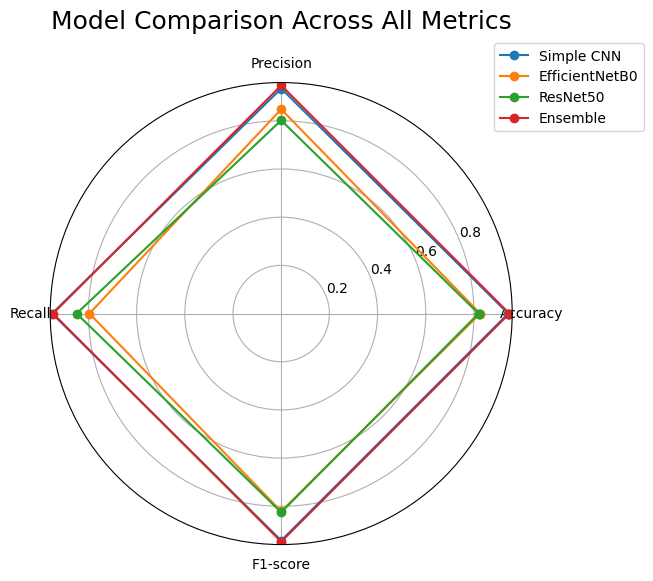

In [31]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

cnn_scores = [0.942, 0.934, 0.951, 0.942]
eff_scores = [0.826, 0.848, 0.796, 0.821]
res_scores = [0.819, 0.802, 0.849, 0.825]
ensemble_scores = [0.947, 0.947, 0.947, 0.947]

model_names = ["Simple CNN", "EfficientNetB0", "ResNet50", "Ensemble"]

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(10,6))

for scores, name in zip([cnn_scores, eff_scores, res_scores, ensemble_scores], model_names):
    scores = np.concatenate((scores, [scores[0]]))
    plt.polar(angles, scores, marker='o', label=name)

plt.xticks(angles[:-1], metrics)
plt.title("Model Comparison Across All Metrics", size=18, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.grid(True)

plt.show()